# St. Louis ZIP Code Deep Dive

This notebook extends the Missouri county-level care gap analysis
to the ZIP/ZCTA level for the St. Louis region.

The goal is to identify ZIP Code Tabulation Areas where social
vulnerability, chronic disease burden, uninsured burden, and limited
care coordination resources may overlap.

This phase supports operational targeting for health systems, FQHCs,
population health teams, and ConnexiCare-style care coordination planning.

In [26]:
# Import core libraries for ZIP-level analysis

import pandas as pd
import numpy as np
from pathlib import Path
import geopandas as gpd

# Define project folders

DATA_RAW = Path("data/raw")
DATA_PROCESSED = Path("data/processed")
OUTPUTS = Path("outputs/charts")

# Create folders
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
OUTPUTS.mkdir(parents=True, exist_ok=True)

## Step 1 — Load and Prepare CDC PLACES ZCTA Data

This section loads CDC PLACES ZIP/ZCTA-level health burden data
for localized analysis within the St. Louis region.

ZIP-level analysis provides more operational granularity than
county-level analysis and may better identify vulnerable
neighborhood-level populations.

In [5]:
# Load CDC PLACES ZIP/ZCTA-level data

places_zcta = pd.read_csv(
    "places_zcta.csv",
    low_memory=False
)

# Preview dataset
places_zcta.head()

,Year,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,TotalPop18plus,TotalPopulation,Geolocation,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text
0,2023,1001,BRFSS,Prevention,Current lack of health insurance among adults ...,%,Crude prevalence,4.5,NaN,NaN,3.8,5.3,"14,019","16,984",POINT (-72.6257536 42.0623678),1001,PREVENT,ACCESS2,CrdPrv,Health Insurance
1,2023,1001,BRFSS,Health Outcomes,Arthritis among adults,%,Crude prevalence,31.8,NaN,NaN,29.0,34.7,"14,019","16,984",POINT (-72.6257536 42.0623678),1001,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis
2,2023,1001,BRFSS,Health Risk Behaviors,Binge drinking among adults,%,Crude prevalence,16.7,NaN,NaN,14.2,19.2,"14,019","16,984",POINT (-72.6257536 42.0623678),1001,RISKBEH,BINGE,CrdPrv,Binge Drinking
3,2023,1001,BRFSS,Health Outcomes,High blood pressure among adults,%,Crude prevalence,34.8,NaN,NaN,31.6,38.1,"14,019","16,984",POINT (-72.6257536 42.0623678),1001,HLTHOUT,BPHIGH,CrdPrv,High Blood Pressure
4,2023,1001,BRFSS,Prevention,Taking medicine to control high blood pressure...,%,Crude prevalence,78.3,NaN,NaN,75.5,80.9,"14,019","16,984",POINT (-72.6257536 42.0623678),1001,PREVENT,BPMED,CrdPrv,High Blood Pressure Medication


In [6]:
# Review important analytical columns

places_zcta[[
    "Year",
    "LocationName",
    "Measure",
    "Data_Value"
]].head()

,Year,LocationName,Measure,Data_Value
0,2023,1001,Current lack of health insurance among adults ...,4.5
1,2023,1001,Arthritis among adults,31.8
2,2023,1001,Binge drinking among adults,16.7
3,2023,1001,High blood pressure among adults,34.8
4,2023,1001,Taking medicine to control high blood pressure...,78.3


In [8]:
# Preview measure identifiers

places_zcta[[
    "Measure",
    "MeasureId"
]].drop_duplicates().head(5)

,Measure,MeasureId
0,Current lack of health insurance among adults ...,ACCESS2
1,Arthritis among adults,ARTHRITIS
2,Binge drinking among adults,BINGE
3,High blood pressure among adults,BPHIGH
4,Taking medicine to control high blood pressure...,BPMED


In [9]:
# Select core health burden indicators

needed_measures = [
    "ACCESS2",   # uninsured burden
    "MHLTH",     # poor mental health
    "DIABETES",
    "BPHIGH",
    "OBESITY",
    "COPD"
]

zcta_filtered = places_zcta[
    places_zcta["MeasureId"].isin(needed_measures)
].copy()

# Preview filtered data
zcta_filtered.head()

,Year,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,TotalPop18plus,TotalPopulation,Geolocation,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text
0,2023,1001,BRFSS,Prevention,Current lack of health insurance among adults ...,%,Crude prevalence,4.5,NaN,NaN,3.8,5.3,"14,019","16,984",POINT (-72.6257536 42.0623678),1001,PREVENT,ACCESS2,CrdPrv,Health Insurance
3,2023,1001,BRFSS,Health Outcomes,High blood pressure among adults,%,Crude prevalence,34.8,NaN,NaN,31.6,38.1,"14,019","16,984",POINT (-72.6257536 42.0623678),1001,HLTHOUT,BPHIGH,CrdPrv,High Blood Pressure
12,2023,1001,BRFSS,Health Outcomes,Chronic obstructive pulmonary disease among ad...,%,Crude prevalence,7.3,NaN,NaN,6.3,8.3,"14,019","16,984",POINT (-72.6257536 42.0623678),1001,HLTHOUT,COPD,CrdPrv,COPD
16,2023,1001,BRFSS,Health Outcomes,Diagnosed diabetes among adults,%,Crude prevalence,10.6,NaN,NaN,9.3,12.1,"14,019","16,984",POINT (-72.6257536 42.0623678),1001,HLTHOUT,DIABETES,CrdPrv,Diabetes
30,2023,1001,BRFSS,Health Status,Frequent mental distress among adults,%,Crude prevalence,17.4,NaN,NaN,15.6,19.4,"14,019","16,984",POINT (-72.6257536 42.0623678),1001,HLTHSTAT,MHLTH,CrdPrv,Frequent Mental Distress


### Indicator Selection

The selected indicators represent key dimensions of healthcare
vulnerability, including uninsured burden, chronic disease burden,
mental health burden, and risk-factor prevalence.

These indicators will later be combined into a localized ZIP-level
SDOH vulnerability framework for the St. Louis region.

In [10]:
# Convert long-format CDC data into ZIP-level analytical table

zcta_health = zcta_filtered.pivot_table(
    index=["LocationName"],
    columns="MeasureId",
    values="Data_Value",
    aggfunc="first"
).reset_index()

# Preview ZIP-level table
zcta_health.head()

MeasureId,LocationName,ACCESS2,BPHIGH,COPD,DIABETES,MHLTH,OBESITY
0,1001,4.5,34.8,7.3,10.6,17.4,31.6
1,1002,4.6,24.4,5.1,7.9,17.8,21.3
2,1003,4.1,6.8,1.2,1.0,24.9,13.9
3,1005,4.9,35.4,8.1,11.1,18.9,34.3
4,1007,3.5,29.9,6.0,9.1,15.8,24.2


In [11]:
# Rename columns for easier analysis

zcta_health = zcta_health.rename(columns={
    "LocationName": "zcta",
    "ACCESS2": "uninsured_rate",
    "MHLTH": "poor_mental_health",
    "DIABETES": "diabetes_rate",
    "BPHIGH": "high_bp_rate",
    "OBESITY": "obesity_rate",
    "COPD": "copd_rate"
})

# Preview renamed dataset
zcta_health.head()

MeasureId,zcta,uninsured_rate,high_bp_rate,copd_rate,diabetes_rate,poor_mental_health,obesity_rate
0,1001,4.5,34.8,7.3,10.6,17.4,31.6
1,1002,4.6,24.4,5.1,7.9,17.8,21.3
2,1003,4.1,6.8,1.2,1.0,24.9,13.9
3,1005,4.9,35.4,8.1,11.1,18.9,34.3
4,1007,3.5,29.9,6.0,9.1,15.8,24.2


## Step 2 — ACS ZIP/ZCTA Socioeconomic Data from Census API

This section retrieves ACS 5-Year ZIP/ZCTA-level socioeconomic data
directly from the Census API.

The variables include total population, poverty count, poverty universe,
and median household income. These indicators strengthen the ZIP-level
SDOH vulnerability model by adding socioeconomic burden to the CDC
PLACES health indicators.

In [13]:
# Pull ACS 2023 5-Year ZCTA-level socioeconomic data from Census API
# B01003_001E = total population
# B17001_001E = poverty universe
# B17001_002E = population below poverty
# B19013_001E = median household income

acs_zcta_url = (
    "https://api.census.gov/data/2023/acs/acs5"
    "?get=NAME,B01003_001E,B17001_001E,B17001_002E,B19013_001E"
    "&for=zip%20code%20tabulation%20area:*"
)

acs_zcta = pd.read_json(acs_zcta_url)

# Use first row as column names
acs_zcta.columns = acs_zcta.iloc[0]

# Remove header row
acs_zcta = acs_zcta.iloc[1:].copy()

# Preview data
acs_zcta.head()

,NAME,B01003_001E,B17001_001E,B17001_002E,B19013_001E,zip code tabulation area
1,ZCTA5 00601,16721,16676,10199,18571,00601
2,ZCTA5 00602,37510,37419,17504,21702,00602
3,ZCTA5 00603,48317,47655,22683,19243,00603
4,ZCTA5 00606,5435,5435,2984,20226,00606
5,ZCTA5 00610,25413,25312,11145,23732,00610


In [14]:
# Rename ACS variables into readable analytical names

acs_zcta = acs_zcta.rename(columns={
    "NAME": "zcta_name",
    "B01003_001E": "population",
    "B17001_001E": "poverty_universe",
    "B17001_002E": "poverty_count",
    "B19013_001E": "median_household_income",
    "zip code tabulation area": "zcta"
})

# Preview renamed data
acs_zcta.head()

,zcta_name,population,poverty_universe,poverty_count,median_household_income,zcta
1,ZCTA5 00601,16721,16676,10199,18571,00601
2,ZCTA5 00602,37510,37419,17504,21702,00602
3,ZCTA5 00603,48317,47655,22683,19243,00603
4,ZCTA5 00606,5435,5435,2984,20226,00606
5,ZCTA5 00610,25413,25312,11145,23732,00610


In [15]:
# Convert numeric ACS fields from text to numeric values

numeric_cols = [
    "population",
    "poverty_universe",
    "poverty_count",
    "median_household_income"
]

for col in numeric_cols:
    acs_zcta[col] = pd.to_numeric(
        acs_zcta[col],
        errors="coerce"
    )

# Ensure ZCTA is formatted as 5-digit text
acs_zcta["zcta"] = (
    acs_zcta["zcta"]
    .astype(str)
    .str.zfill(5)
)

acs_zcta.head()

,zcta_name,population,poverty_universe,poverty_count,median_household_income,zcta
1,ZCTA5 00601,16721,16676,10199,18571,00601
2,ZCTA5 00602,37510,37419,17504,21702,00602
3,ZCTA5 00603,48317,47655,22683,19243,00603
4,ZCTA5 00606,5435,5435,2984,20226,00606
5,ZCTA5 00610,25413,25312,11145,23732,00610


In [16]:
# Calculate ZIP/ZCTA poverty rate

acs_zcta["poverty_rate"] = (
    acs_zcta["poverty_count"] /
    acs_zcta["poverty_universe"]
) * 100

# Preview calculated poverty rate
acs_zcta[[
    "zcta",
    "population",
    "poverty_rate",
    "median_household_income"
]].head()

,zcta,population,poverty_rate,median_household_income
1,00601,16721,61.159751,18571
2,00602,37510,46.778375,21702
3,00603,48317,47.598363,19243
4,00606,5435,54.903404,20226
5,00610,25413,44.030499,23732


In [17]:
# Merge CDC PLACES health indicators with ACS socioeconomic indicators

zcta_project = zcta_health.merge(
    acs_zcta[[
        "zcta",
        "population",
        "poverty_rate",
        "median_household_income"
    ]],
    on="zcta",
    how="left"
)

# Preview merged ZIP-level dataset
zcta_project.head()

,zcta,uninsured_rate,high_bp_rate,copd_rate,diabetes_rate,poor_mental_health,obesity_rate,population,poverty_rate,median_household_income
0,01001,4.5,34.8,7.3,10.6,17.4,31.6,16136.0,7.232463,71924.0
1,01002,4.6,24.4,5.1,7.9,17.8,21.3,24726.0,22.951122,69411.0
2,01003,4.1,6.8,1.2,1.0,24.9,13.9,12458.0,13.846154,-666666666.0
3,01005,4.9,35.4,8.1,11.1,18.9,34.3,4786.0,12.545338,97390.0
4,01007,3.5,29.9,6.0,9.1,15.8,24.2,15406.0,8.708650,99056.0


## Step 3 — Filter and Prepare St. Louis ZIP/ZCTA Dataset

This section isolates ZIP/ZCTA regions within the St. Louis area
for localized healthcare vulnerability analysis.

Additional data cleaning is performed to address Census missing-value
codes and improve analytical consistency.

In [19]:
# Replace invalid Census income codes with missing values

zcta_project["median_household_income"] = (
    zcta_project["median_household_income"]
    .replace(-666666666.0, np.nan)
)

# Check missing income values
zcta_project["median_household_income"].isna().sum()

np.int64(1965)

In [20]:
# Filter St. Louis ZIP/ZCTA regions
# Primary St. Louis ZIP codes begin with 631

stl_zcta = zcta_project[
    zcta_project["zcta"].str.startswith("631")
].copy()

# Check number of St. Louis ZIP areas
stl_zcta.shape

(45, 10)

### St. Louis ZIP-Level Focus

The St. Louis regional ZIP/ZCTA subset enables more localized
analysis of healthcare vulnerability patterns than county-level
analysis alone.

ZIP-level analysis may better capture neighborhood-level variation
in socioeconomic burden, chronic disease prevalence, and healthcare
access disparities.

In [21]:
# Summary statistics for St. Louis ZIP-level indicators

stl_zcta[[
    "population",
    "poverty_rate",
    "uninsured_rate",
    "poor_mental_health",
    "diabetes_rate",
    "high_bp_rate",
    "obesity_rate",
    "copd_rate"
]].describe()

,population,poverty_rate,uninsured_rate,poor_mental_health,diabetes_rate,high_bp_rate,obesity_rate,copd_rate
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,19820.155556,16.769285,8.800000,17.906667,13.366667,37.977778,35.384444,7.475556
std,12588.439939,11.039674,3.471115,3.281311,5.457688,8.649091,8.206149,2.831893
min,350.000000,2.059355,3.700000,11.700000,7.100000,25.800000,23.900000,3.800000
25%,9188.000000,6.691256,5.800000,15.100000,9.400000,32.100000,28.400000,5.100000
50%,18701.000000,15.460503,7.600000,17.900000,11.300000,34.500000,34.900000,6.900000
75%,25743.000000,25.758435,12.300000,20.600000,17.100000,44.400000,42.900000,10.000000
max,51356.000000,42.857143,15.600000,25.600000,24.100000,53.900000,49.800000,13.400000


In [23]:
# Create preliminary ZIP-level SDOH vulnerability score

score_columns = [
    "poverty_rate",
    "uninsured_rate",
    "poor_mental_health",
    "diabetes_rate",
    "high_bp_rate",
    "obesity_rate",
    "copd_rate"
]

# Convert indicators to percentile ranks
for col in score_columns:
    
    score_name = col + "_score"
    
    stl_zcta[score_name] = (
        stl_zcta[col]
        .rank(pct=True) * 100
    )

# Create combined ZIP vulnerability index
stl_zcta["zip_sdoh_vulnerability_index"] = (
    stl_zcta[
        [col + "_score" for col in score_columns]
    ].mean(axis=1)
)

# Preview scores
stl_zcta[[
    "zcta",
    "zip_sdoh_vulnerability_index"
]].head()

,zcta,zip_sdoh_vulnerability_index
18950,63101,43.174603
18951,63102,36.984127
18952,63103,58.253968
18953,63104,45.396825
18954,63105,14.126984


In [24]:
# Rank ZIP codes by vulnerability

stl_zcta = stl_zcta.sort_values(
    "zip_sdoh_vulnerability_index",
    ascending=False
)

# Display highest-risk ZIP areas
stl_zcta[[
    "zcta",
    "zip_sdoh_vulnerability_index",
    "poverty_rate",
    "uninsured_rate",
    "poor_mental_health"
]].head(20)

,zcta,zip_sdoh_vulnerability_index,poverty_rate,uninsured_rate,poor_mental_health
18969,63120,96.666667,30.165826,15.6,22.5
18955,63106,93.492063,40.950521,13.8,23.0
18964,63115,90.793651,31.338003,12.8,20.5
18956,63107,88.412698,21.521377,13.3,21.0
18962,63113,87.777778,29.440433,12.8,20.6
18994,63147,87.301587,35.331390,12.3,20.1
18985,63136,86.190476,27.231026,12.8,21.4
18986,63137,83.333333,27.055183,12.4,22.0
18982,63133,83.174603,30.081433,12.6,21.0
18983,63134,81.746032,28.364808,13.9,21.7


### Interpretation

The ZIP-level vulnerability ranking identifies localized St. Louis
communities where elevated socioeconomic burden and chronic disease
burden may overlap.

These ZIP areas may represent higher-priority geographies for
care coordination outreach, community health interventions,
and SDOH-focused population health programs.

## Step 4 — St. Louis ZIP/ZCTA Geographic Mapping

This section visualizes ZIP/ZCTA-level healthcare vulnerability
patterns across the St. Louis region using geographic choropleth maps.

ZIP-level mapping supports localized population health analysis
and may help identify neighborhoods with elevated combined
social and health burden.

In [29]:
# Load locally downloaded ZCTA shapefile

zcta_geo = gpd.read_file(
   "C:/Users/brigh/Downloads/tl_2023_us_zcta520.zip")

# Preview geographic dataset
zcta_geo.head()

,ZCTA5CE20,GEOID20,GEOIDFQ20,CLASSFP20,MTFCC20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,geometry
0,47236,47236,860Z200US47236,B5,G6350,S,1029063,0,+39.1517426,-085.7252769,"POLYGON ((-85.7341 39.15597, -85.72794 39.1561..."
1,47870,47870,860Z200US47870,B5,G6350,S,8830,0,+39.3701518,-087.4735141,"POLYGON ((-87.47414 39.37016, -87.47409 39.370..."
2,47851,47851,860Z200US47851,B5,G6350,S,53326,0,+39.5735839,-087.2459559,"POLYGON ((-87.24769 39.5745, -87.24711 39.5744..."
3,47337,47337,860Z200US47337,B5,G6350,S,303089,0,+39.8027537,-085.4372850,"POLYGON ((-85.44357 39.80328, -85.44346 39.803..."
4,47435,47435,860Z200US47435,B5,G6350,S,13302,0,+39.2657557,-086.2951577,"POLYGON ((-86.29592 39.26547, -86.29592 39.266..."


In [30]:
# Standardize ZIP/ZCTA merge keys

zcta_geo["zcta"] = (
    zcta_geo["ZCTA5CE20"]
    .astype(str)
    .str.zfill(5)
)

stl_zcta["zcta"] = (
    stl_zcta["zcta"]
    .astype(str)
    .str.zfill(5)
)

# Preview ZIP formatting
stl_zcta["zcta"].head()

18969    63120
18955    63106
18964    63115
18956    63107
18962    63113
Name: zcta, dtype: object

In [31]:
# Merge ZIP geographic boundaries with analytical dataset

stl_map = zcta_geo.merge(
    stl_zcta,
    on="zcta",
    how="inner"
)

# Preview merged geographic dataset
stl_map.head()

,ZCTA5CE20,GEOID20,GEOIDFQ20,CLASSFP20,MTFCC20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,...,poverty_rate,median_household_income,poverty_rate_score,uninsured_rate_score,poor_mental_health_score,diabetes_rate_score,high_bp_rate_score,obesity_rate_score,copd_rate_score,zip_sdoh_vulnerability_index
0,63117,63117,860Z200US63117,B5,G6350,S,6128594,0,+38.6308113,-090.3304064,...,5.659143,86667.0,20.000000,8.888889,20.000000,10.000000,15.555556,22.222222,8.888889,15.079365
1,63116,63116,860Z200US63116,B5,G6350,S,13988997,10194,+38.5799758,-090.2651419,...,15.460503,60193.0,51.111111,62.222222,56.666667,56.666667,35.555556,52.222222,55.555556,52.857143
2,63136,63136,860Z200US63136,B5,G6350,S,28265352,16007,+38.7447610,-090.2599242,...,27.231026,40388.0,82.222222,84.444444,87.777778,86.666667,88.888889,86.666667,86.666667,86.190476
3,63123,63123,860Z200US63123,B5,G6350,S,32255883,258541,+38.5474323,-090.3281088,...,7.365810,74187.0,31.111111,45.555556,41.111111,43.333333,44.444444,34.444444,53.333333,41.904762
4,63127,63127,860Z200US63127,B5,G6350,S,14997542,139583,+38.5344935,-090.4173867,...,2.628877,124583.0,6.666667,14.444444,6.666667,48.888889,68.888889,8.888889,46.666667,28.730159


In [32]:
# Confirm ZIP geography merge success

stl_map.shape

(45, 29)

### Geographic Merge

ZIP/ZCTA geographic boundaries were merged with the localized
healthcare vulnerability dataset using standardized ZIP/ZCTA identifiers.

This merged geospatial dataset supports neighborhood-level
visualization of healthcare burden patterns across the St. Louis region.

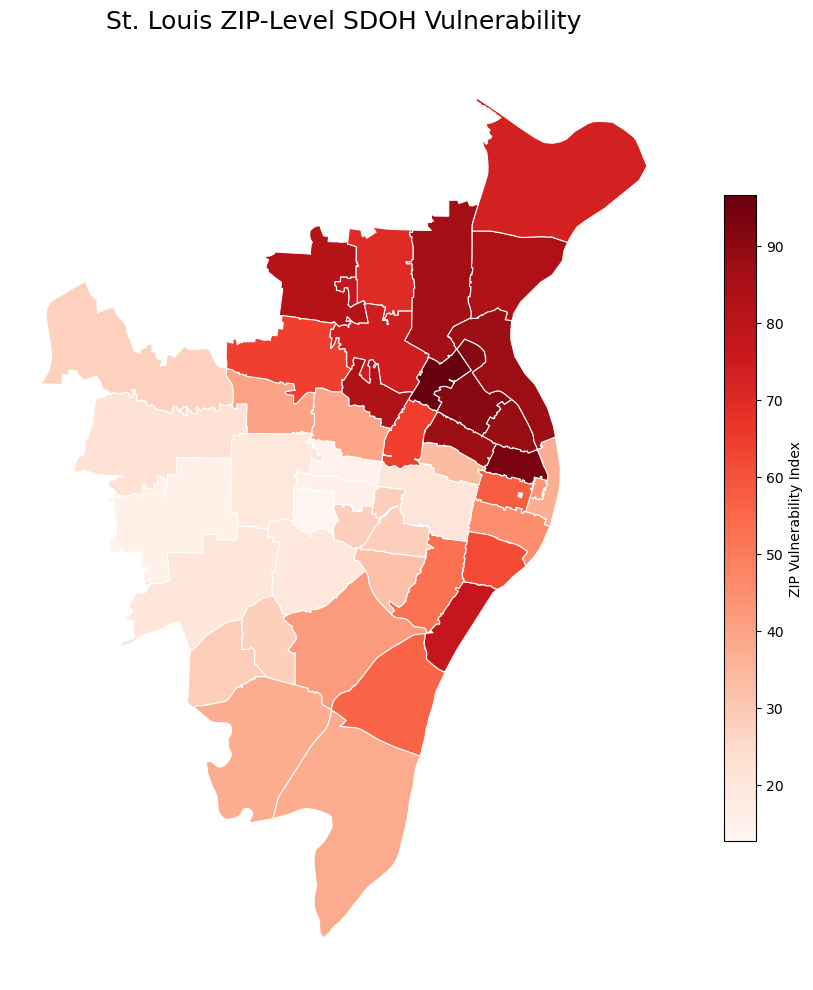

In [34]:
# Create St. Louis ZIP-level vulnerability map
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

stl_map.plot(
    column="zip_sdoh_vulnerability_index",
    cmap="Reds",
    linewidth=0.8,
    edgecolor="white",
    legend=True,
    legend_kwds={
        "label": "ZIP Vulnerability Index",
        "shrink": 0.7
    },
    ax=ax
)

# Add title
ax.set_title(
    "St. Louis ZIP-Level SDOH Vulnerability",
    fontsize=18,
    pad=20
)

# Remove axes
ax.axis("off")

# White background
fig.patch.set_facecolor("white")

# Save map
plt.savefig(
    "outputs/charts/stl_zip_vulnerability_map.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

# Display map
plt.show()

### Interpretation

The St. Louis ZIP-level vulnerability map demonstrates substantial
localized variation in healthcare burden across neighborhoods.

Several northern and central urban ZIP regions demonstrate elevated
combined burden across socioeconomic vulnerability, uninsured burden,
mental health burden, and chronic disease prevalence.

In contrast, several western and southwestern ZIP areas demonstrate
relatively lower composite vulnerability scores.

The geographic clustering observed across the St. Louis region
suggests that healthcare vulnerability may be concentrated within
specific neighborhood-level socioeconomic and healthcare access patterns.

In [35]:
# Save final St. Louis ZIP analytical dataset

stl_zcta.to_csv(
    "data/processed/stl_zip_vulnerability_dataset.csv",
    index=False
)

stl_zcta.to_excel(
    "data/processed/stl_zip_vulnerability_dataset.xlsx",
    index=False
)

print("St. Louis ZIP dataset saved successfully.")

St. Louis ZIP dataset saved successfully.
